In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer

In [ ]:
data = load_breast_cancer()
x = data.data
y = data.target


In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
model = DecisionTreeClassifier(criterion='entropy' , random_state=42)

In [ ]:
model.fit(x_train , y_train)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print(f'Accuracy Score : {accuracy_score(y_test , y_pred)}')
print(f'Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}')Accuracy $0

Accuracy Score : 0.9473684210526315
Confusion Matrix : 
[[38  5]
 [ 1 70]]


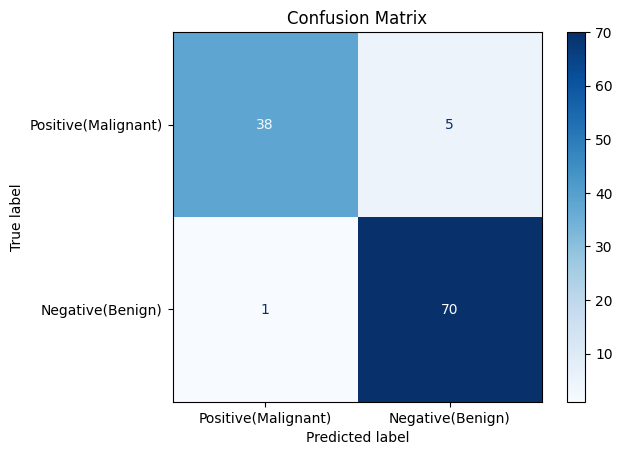

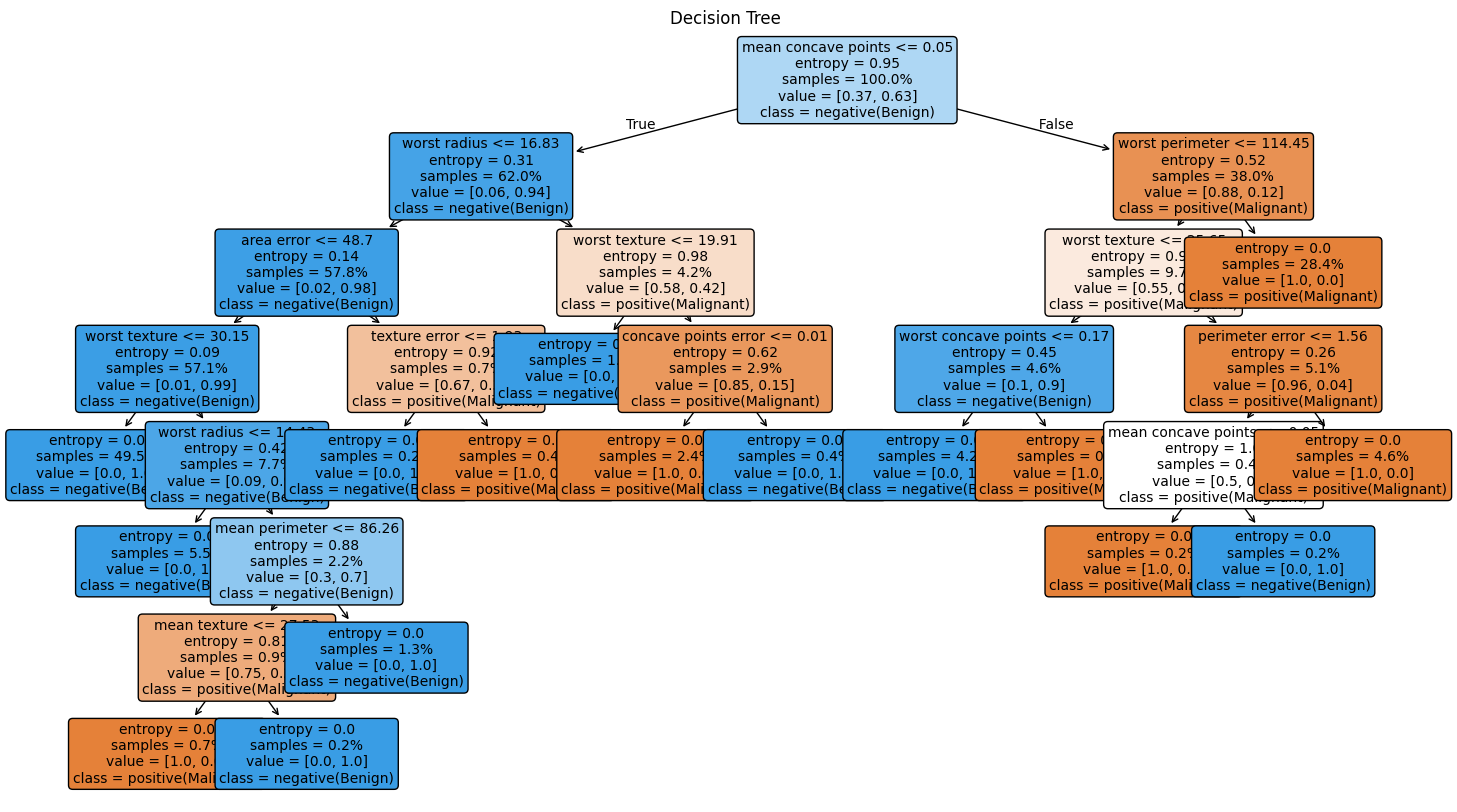

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Positive(Malignant)' , 'Negative(Benign)']
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=[
        'positive(Malignant)' ,
        'negative(Benign)'
    ],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True ,
    precision = 2
)

plt.title("Decision Tree")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'criterion': ['entropy'],
    'max_depth': [3,4,5],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print()

print("Best Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.9341545893719807


In [ ]:
best_model = grid.best_estimator_

best_model.fit(x_train, y_train)

train_pred = best_model.predict(x_train)
test_pred = best_model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.9802197802197802
Testing Accuracy  : 0.9649122807017544
